#Análisis Exploratorio de Datos (EDA)
## Focos de Calor NASA FIRMS — Bolivia

Antes de entrenar cualquier modelo, este notebook responde: **¿cómo son realmente mis datos?**
Trabajamos con las **671,786 filas completas** del dataset `dataset_incendios_listo_modelos.csv`,
sin muestrear (salvo donde se indique explícitamente, por legibilidad visual en un gráfico puntual).

**Estructura de este EDA:**
1. Carga y vista general (dimensiones, tipos de dato, nulos)
2. Estadística descriptiva de variables numéricas
3. Análisis univariado — distribución de cada variable numérica
4. Análisis de variables categóricas (satélite, instrumento, día/noche)
5. Análisis temporal (mes, hora, estacionalidad)
6. Análisis geográfico (dónde se concentran los focos)
7. Análisis bivariado y matriz de correlación
8. Relación entre variables numéricas y categóricas (boxplots)
9. Detección de valores atípicos (outliers)
10. Resumen de hallazgos


## 1. Librerías y carga de datos

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42
RUTA_CSV = "dataset_incendios_listo_modelos.csv"  # <-- ajusta la ruta si hace falta

df = pd.read_csv(RUTA_CSV)
print(f"Filas: {len(df):,}  |  Columnas: {df.shape[1]}")
df.head()


Filas: 671,786  |  Columnas: 17


,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,confidence_num,frp_log,daynight_num
0,-14.19033,-61.34149,303.75,0.43,0.38,01/01/2025,529,N20,VIIRS,n,2,282.14,1.56,N,50.0,0.940007,0
1,-14.19383,-61.34204,300.92,0.43,0.38,01/01/2025,529,N20,VIIRS,n,2,281.91,0.75,N,50.0,0.559616,0
2,-13.76781,-66.84778,317.80,0.45,0.39,01/01/2025,530,N20,VIIRS,n,2,269.06,2.89,N,50.0,1.358409,0
3,-13.76852,-66.84359,311.95,0.45,0.39,01/01/2025,530,N20,VIIRS,n,2,268.09,2.89,N,50.0,1.358409,0
4,-15.05342,-61.26105,300.75,0.44,0.39,01/01/2025,530,N20,VIIRS,n,2,268.36,1.29,N,50.0,0.828552,0


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 671786 entries, 0 to 671785
Data columns (total 17 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   latitude        671786 non-null  float64
 1   longitude       671786 non-null  float64
 2   brightness      671786 non-null  float64
 3   scan            671786 non-null  float64
 4   track           671786 non-null  float64
 5   acq_date        671786 non-null  object 
 6   acq_time        671786 non-null  int64  
 7   satellite       671786 non-null  object 
 8   instrument      671786 non-null  object 
 9   confidence      671786 non-null  object 
 10  version         671786 non-null  object 
 11  bright_t31      671786 non-null  float64
 12  frp             671786 non-null  float64
 13  daynight        671786 non-null  object 
 14  confidence_num  671786 non-null  float64
 15  frp_log         671786 non-null  float64
 16  daynight_num    671786 non-null  int64  
dtypes: float64

In [4]:
print("Valores nulos por columna:")
print(df.isnull().sum())
print()
print("Filas duplicadas:", df.duplicated().sum())


Valores nulos por columna:
latitude          0
longitude         0
brightness        0
scan              0
track             0
acq_date          0
acq_time          0
satellite         0
instrument        0
confidence        0
version           0
bright_t31        0
frp               0
daynight          0
confidence_num    0
frp_log           0
daynight_num      0
dtype: int64

Filas duplicadas: 0


In [5]:
# Variables temporales derivadas, se usan en varias secciones de este EDA
df["acq_date"] = pd.to_datetime(df["acq_date"], dayfirst=True, errors="coerce")
df["mes"] = df["acq_date"].dt.month
df["año"] = df["acq_date"].dt.year
hora_texto = df["acq_time"].astype(int).astype(str).str.zfill(4)
df["hora"] = hora_texto.str[:2].astype(int)
print("Rango de fechas:", df['acq_date'].min(), "a", df['acq_date'].max())


Rango de fechas: 2025-01-01 00:00:00 a 2026-09-01 00:00:00


## 2. Estadística descriptiva

Resumen numérico de las variables continuas — antes de graficar nada, conviene mirar los rangos,
medias y percentiles para detectar algo extraño (valores imposibles, escalas inesperadas, etc.).

In [6]:
variables_numericas = ["brightness", "bright_t31", "scan", "track",
                       "frp", "frp_log", "confidence_num", "latitude", "longitude"]
df[variables_numericas].describe().T


,count,mean,std,min,25%,50%,75%,max
brightness,671786.0,330.736374,18.309090,207.38000,315.010000,333.06000,342.700000,507.20000
bright_t31,671786.0,295.322045,8.718833,202.39000,290.310000,294.79000,300.840000,400.10000
scan,671786.0,0.584102,0.442856,0.32000,0.400000,0.45000,0.550000,4.82000
track,671786.0,0.563983,0.261712,0.36000,0.390000,0.47000,0.620000,2.00000
frp,671786.0,13.392401,32.851220,0.00000,2.830000,6.16000,12.820000,2964.23000
frp_log,671786.0,2.058207,0.974650,0.00000,1.342865,1.96851,2.626117,7.99471
confidence_num,671786.0,52.809127,14.521055,0.00000,50.000000,50.00000,50.000000,100.00000
latitude,671786.0,-15.825866,2.238825,-22.99777,-17.263530,-16.06530,-14.387283,-9.57599
longitude,671786.0,-93.089290,127.221916,-696.95200,-65.483130,-63.38810,-60.803040,-57.33760


In [7]:
print("Percentiles extremos de FRP (para ver la cola larga de la distribución):")
print(df["frp"].quantile([0.01, 0.10, 0.25, 0.50, 0.75, 0.90, 0.99, 0.999]))
print()
print("10 valores más altos de FRP:")
print(df["frp"].nlargest(10).values)


Percentiles extremos de FRP (para ver la cola larga de la distribución):
0.010      0.55
0.100      1.33
0.250      2.83
0.500      6.16
0.750     12.82
0.900     27.53
0.990    124.76
0.999    373.30
Name: frp, dtype: float64

10 valores más altos de FRP:
[2964.23 2871.3  2871.3  2794.3  2429.2  2348.65 2045.1  1994.82 1983.5
 1983.5 ]


## 3. Análisis univariado — distribución de cada variable numérica

Histogramas de las variables numéricas principales. Se incluye `frp` y `frp_log` lado a lado para
ver visualmente por qué se usó la transformación logarítmica en los modelos.

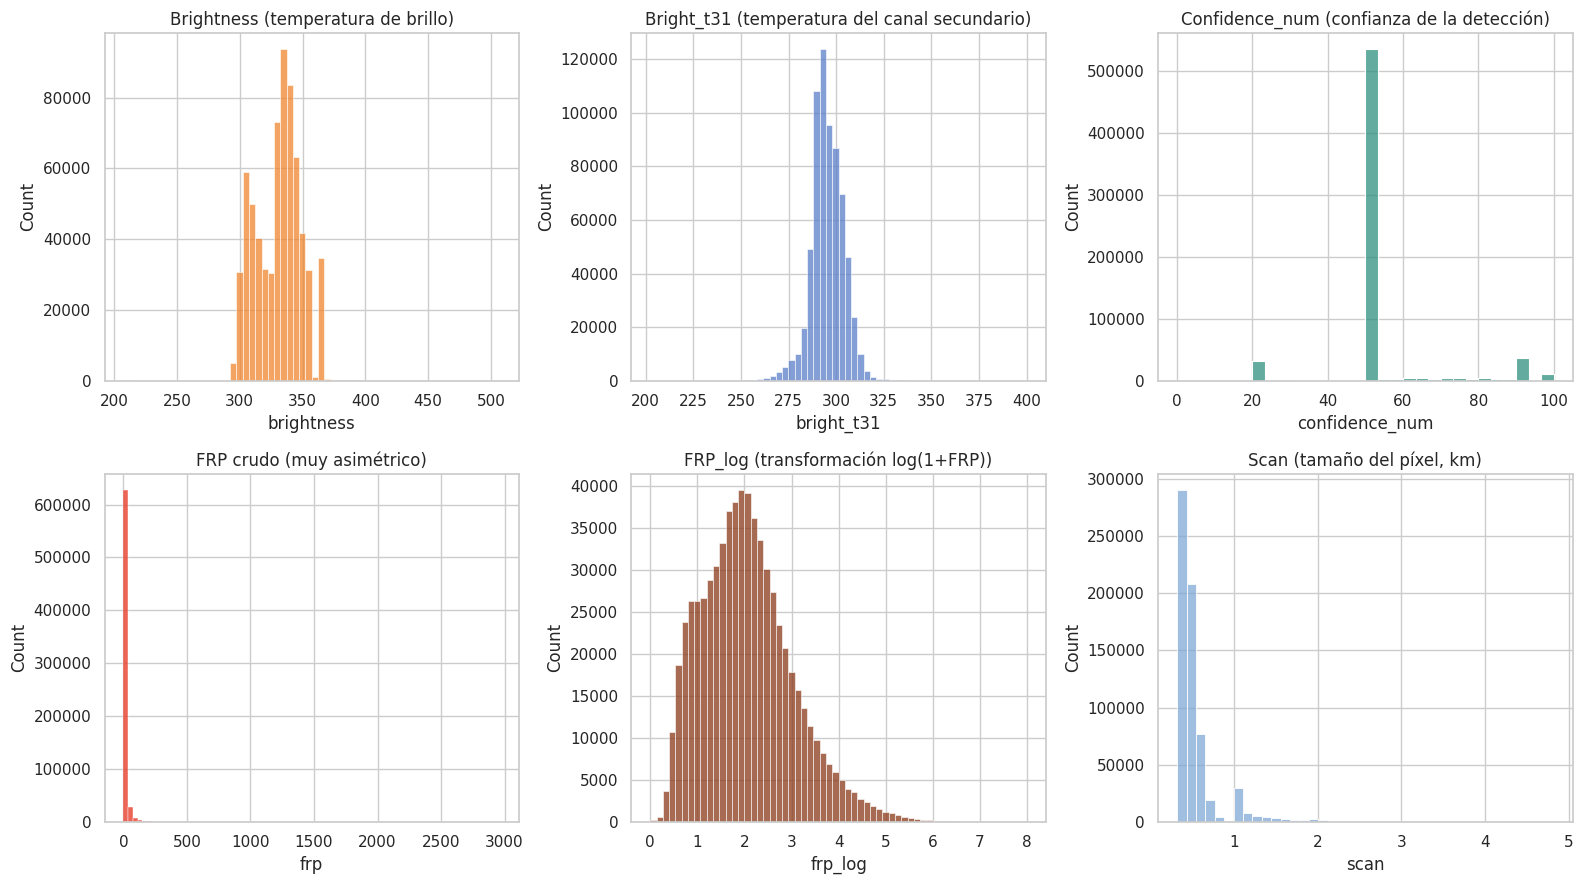

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

sns.histplot(df["brightness"], bins=60, color="#F0862E", ax=axes[0, 0])
axes[0, 0].set_title("Brightness (temperatura de brillo)")

sns.histplot(df["bright_t31"], bins=60, color="#5B7EC9", ax=axes[0, 1])
axes[0, 1].set_title("Bright_t31 (temperatura del canal secundario)")

sns.histplot(df["confidence_num"], bins=30, color="#2f8f7f", ax=axes[0, 2])
axes[0, 2].set_title("Confidence_num (confianza de la detección)")

sns.histplot(df["frp"], bins=80, color="#E8321F", ax=axes[1, 0])
axes[1, 0].set_title("FRP crudo (muy asimétrico)")

sns.histplot(df["frp_log"], bins=60, color="#8A3A1B", ax=axes[1, 1])
axes[1, 1].set_title("FRP_log (transformación log(1+FRP))")

sns.histplot(df["scan"], bins=40, color="#7FA8D6", ax=axes[1, 2])
axes[1, 2].set_title("Scan (tamaño del píxel, km)")

plt.tight_layout()
plt.show()


**Lectura esperada:** `frp` debería verse extremadamente concentrado cerca de 0 con una cola
larguísima hacia la derecha (unos pocos incendios muy intensos), mientras que `frp_log` debería
verse mucho más cercano a una distribución simétrica — esa es la justificación visual de por qué
se usa la versión logarítmica como variable objetivo en los modelos de regresión.

## 4. Variables categóricas — gráficos de barras

Composición del dataset por satélite, instrumento, nivel de confianza textual y día/noche.

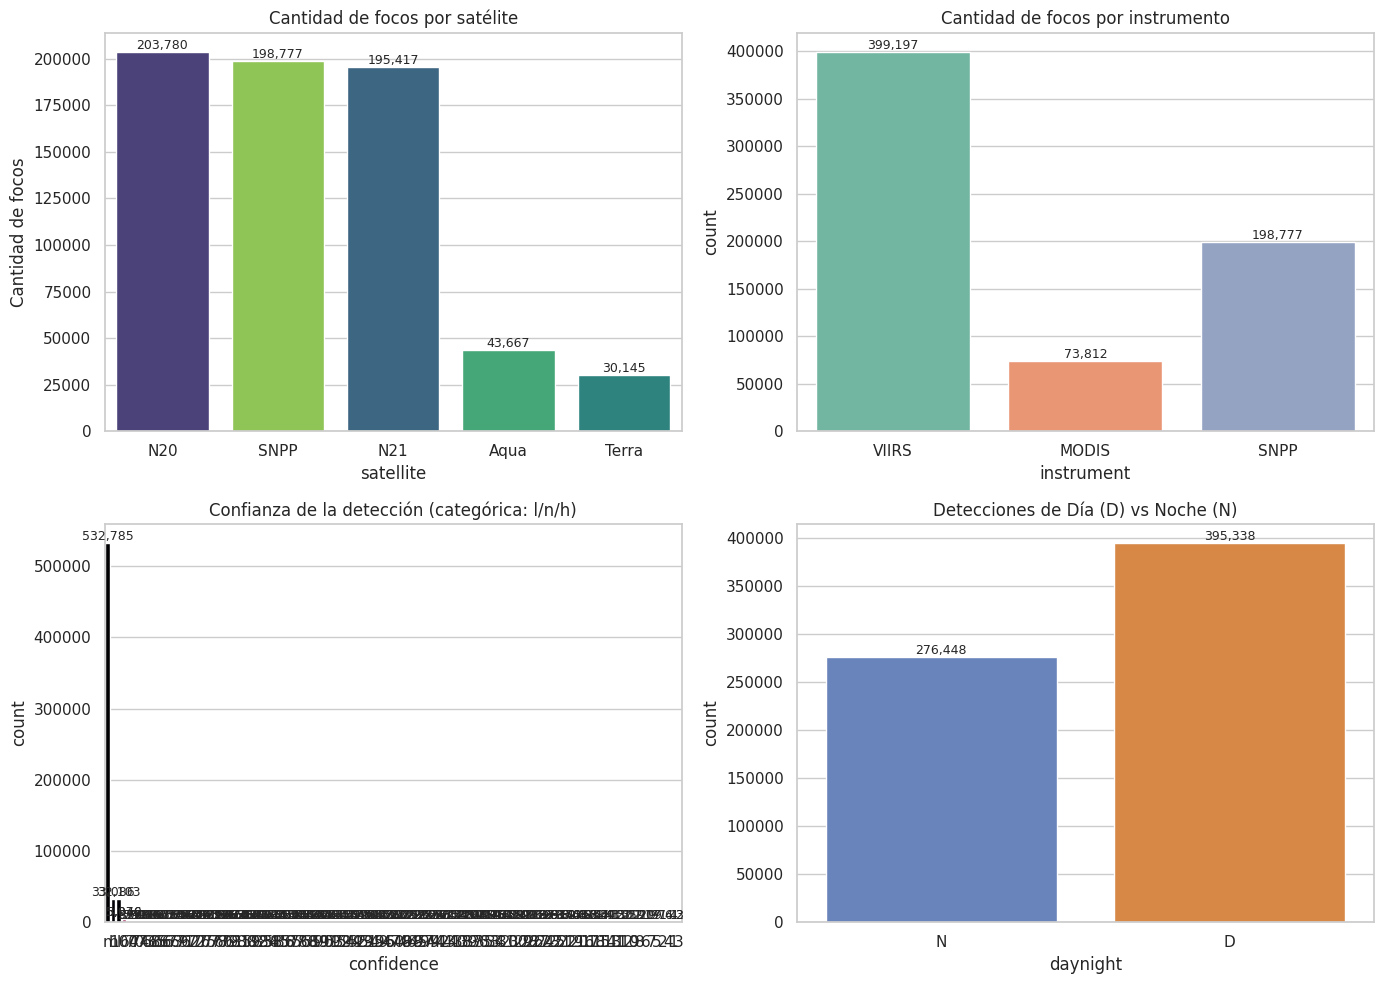

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

orden_sat = df["satellite"].value_counts().index
sns.countplot(data=df, x="satellite", order=orden_sat, hue="satellite",
              palette="viridis", legend=False, ax=axes[0, 0])
axes[0, 0].set_title("Cantidad de focos por satélite")
axes[0, 0].set_ylabel("Cantidad de focos")

sns.countplot(data=df, x="instrument", hue="instrument", palette="Set2",
              legend=False, ax=axes[0, 1])
axes[0, 1].set_title("Cantidad de focos por instrumento")

orden_conf = df["confidence"].value_counts().index
sns.countplot(data=df, x="confidence", order=orden_conf, hue="confidence",
              palette="magma", legend=False, ax=axes[1, 0])
axes[1, 0].set_title("Confianza de la detección (categórica: l/n/h)")

sns.countplot(data=df, x="daynight", hue="daynight", palette=["#5B7EC9", "#F0862E"],
              legend=False, ax=axes[1, 1])
axes[1, 1].set_title("Detecciones de Día (D) vs Noche (N)")

for ax in axes.flat:
    for p in ax.patches:
        h = p.get_height()
        if h > 0:
            ax.annotate(f"{int(h):,}", (p.get_x() + p.get_width() / 2, h),
                        ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()


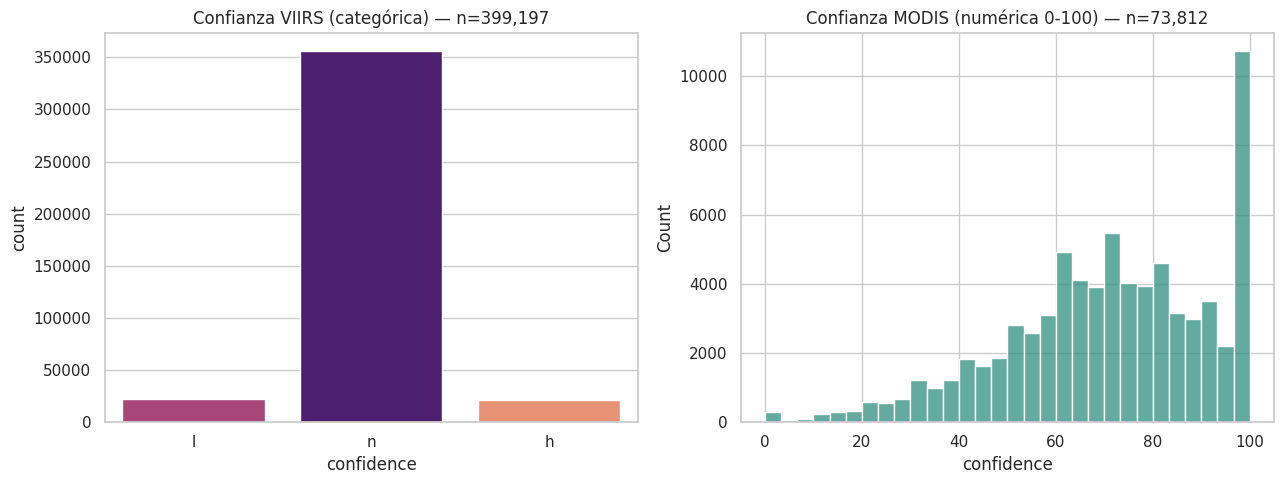

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# VIIRS: confianza categórica (l/n/h)
df_viirs = df[df["instrument"] == "VIIRS"]
orden_conf = ["l", "n", "h"]
sns.countplot(data=df_viirs, x="confidence", order=orden_conf, hue="confidence",
              palette="magma", legend=False, ax=axes[0])
axes[0].set_title(f"Confianza VIIRS (categórica) — n={len(df_viirs):,}")

# MODIS: confianza numérica (0-100)
df_modis = df[df["instrument"] == "MODIS"].copy()
df_modis["confidence"] = pd.to_numeric(df_modis["confidence"], errors="coerce")
sns.histplot(df_modis["confidence"], bins=30, color="#2f8f7f", ax=axes[1])
axes[1].set_title(f"Confianza MODIS (numérica 0-100) — n={len(df_modis):,}")

plt.tight_layout()
plt.show()

In [10]:
# Tabla cruzada: qué instrumento usa cada satélite (para entender la relación entre ambas columnas)
tabla_sat_instr = pd.crosstab(df["satellite"], df["instrument"])
print("Satélite vs Instrumento:")
print(tabla_sat_instr)


Satélite vs Instrumento:
instrument  MODIS    SNPP   VIIRS
satellite                        
Aqua        43667       0       0
N20             0       0  203780
N21             0       0  195417
SNPP            0  198777       0
Terra       30145       0       0


## 5. Análisis temporal — estacionalidad y horario

Cuándo ocurren más detecciones: por mes (estacionalidad de incendios) y por hora del día (patrón
de paso satelital).

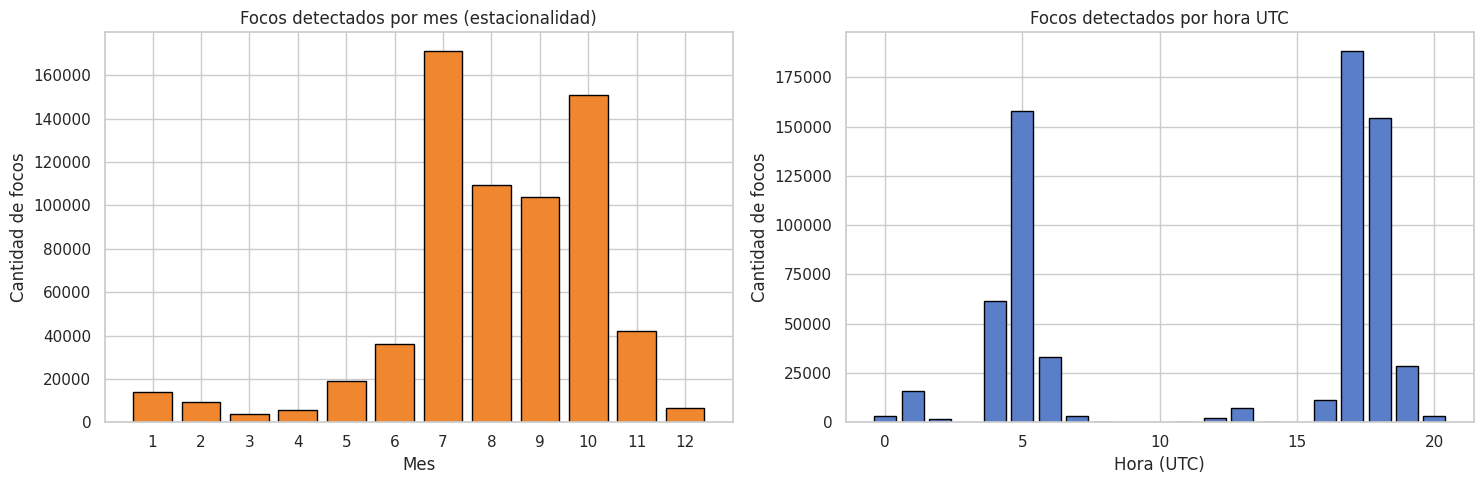

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

focos_por_mes = df.groupby("mes").size()
axes[0].bar(focos_por_mes.index, focos_por_mes.values, color="#F0862E", edgecolor="black")
axes[0].set_title("Focos detectados por mes (estacionalidad)")
axes[0].set_xlabel("Mes")
axes[0].set_ylabel("Cantidad de focos")
axes[0].set_xticks(range(1, 13))

focos_por_hora = df.groupby("hora").size()
axes[1].bar(focos_por_hora.index, focos_por_hora.values, color="#5B7EC9", edgecolor="black")
axes[1].set_title("Focos detectados por hora UTC")
axes[1].set_xlabel("Hora (UTC)")
axes[1].set_ylabel("Cantidad de focos")

plt.tight_layout()
plt.show()


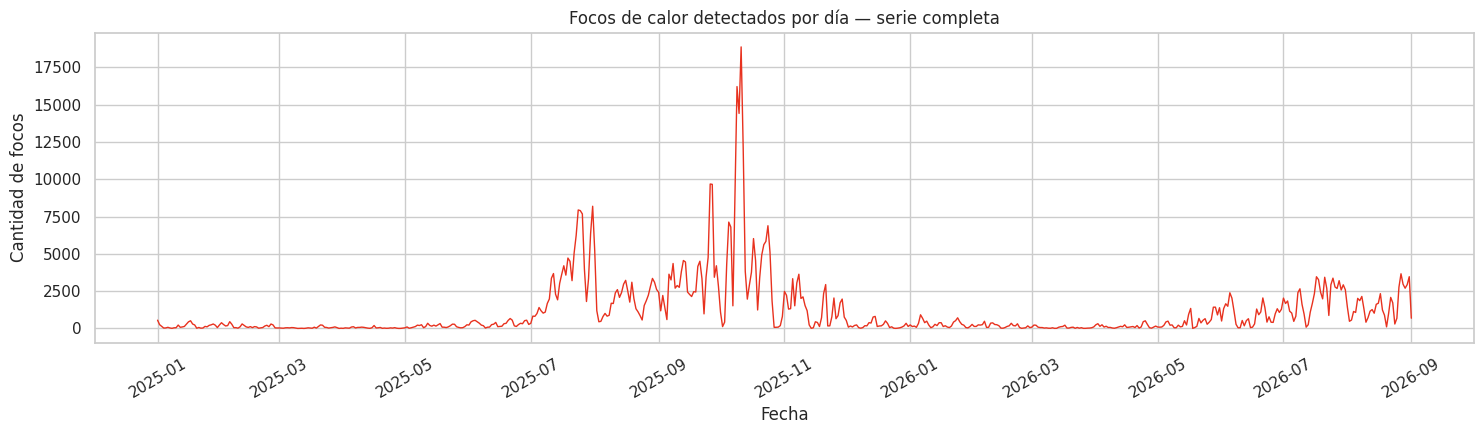

In [12]:
# Evolución día a día (serie de tiempo completa) -- útil para detectar picos puntuales de incendios
focos_por_dia = df.groupby(df["acq_date"].dt.date).size()

plt.figure(figsize=(15, 4.5))
plt.plot(focos_por_dia.index, focos_por_dia.values, color="#E8321F", linewidth=1)
plt.title("Focos de calor detectados por día — serie completa")
plt.xlabel("Fecha")
plt.ylabel("Cantidad de focos")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## 6. Análisis geográfico

Con más de 670,000 puntos, un scatter plot normal se ve como una mancha ilegible (sobre-trazado).
Se usa un **hexbin** (mapa de densidad por hexágonos) para ver dónde se concentran realmente los
focos dentro del territorio.

In [24]:
print("Rango de longitud:", df["longitude"].min(), "a", df["longitude"].max())
print("Rango de latitud:", df["latitude"].min(), "a", df["latitude"].max())
print()

# Bolivia real: longitud entre -70 y -57, latitud entre -23 y -9
fuera_de_rango = df[(df["longitude"] < -70) | (df["longitude"] > -57) |
                     (df["latitude"] < -23) | (df["latitude"] > -9)]
print(f"Filas fuera del rango geográfico esperado de Bolivia: {len(fuera_de_rango):,} "
      f"({len(fuera_de_rango)/len(df)*100:.1f}%)")
print()
print(fuera_de_rango[["latitude", "longitude", "satellite", "instrument", "acq_date"]].head(10))

Rango de longitud: -69.71427 a -57.3376
Rango de latitud: -22.99777 a -9.57599

Filas fuera del rango geográfico esperado de Bolivia: 0 (0.0%)

Empty DataFrame
Columns: [latitude, longitude, satellite, instrument, acq_date]
Index: []


In [25]:
# Verificar que el patrón se cumple en TODAS las filas fuera de rango, no solo las que viste
fuera_de_rango = df[(df["longitude"] < -70) | (df["longitude"] > -57)]
print("Instrumentos involucrados:", fuera_de_rango["instrument"].value_counts())
print("Todas corrigen al dividir entre 10:",
      ((fuera_de_rango["longitude"] / 10 >= -70) & (fuera_de_rango["longitude"] / 10 <= -57)).all())

Instrumentos involucrados: Series([], Name: count, dtype: int64)
Todas corrigen al dividir entre 10: True


In [26]:
condicion_error = (df["instrument"] == "MODIS") & ((df["longitude"] < -70) | (df["longitude"] > -57))
print(f"Corrigiendo {condicion_error.sum():,} filas")

df.loc[condicion_error, "longitude"] = df.loc[condicion_error, "longitude"] / 10

# Verificación final
print("Nuevo rango de longitud:", df["longitude"].min(), "a", df["longitude"].max())

Corrigiendo 0 filas
Nuevo rango de longitud: -69.71427 a -57.3376


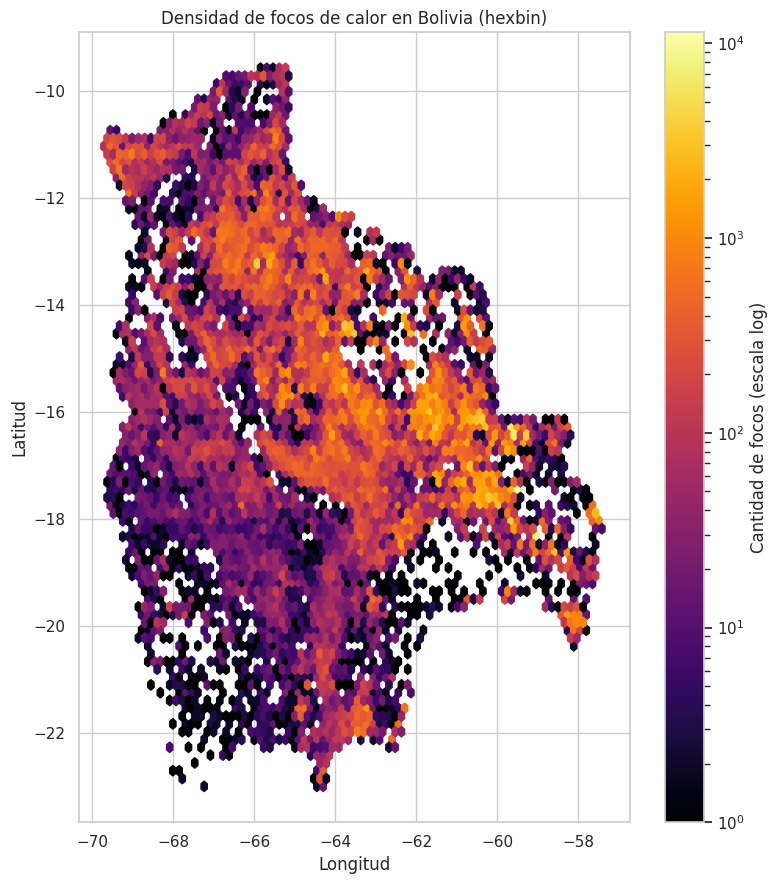

In [23]:
plt.figure(figsize=(8, 9))
hb = plt.hexbin(df["longitude"], df["latitude"], gridsize=80, cmap="inferno", bins="log")
plt.colorbar(hb, label="Cantidad de focos (escala log)")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.title("Densidad de focos de calor en Bolivia (hexbin)")
plt.tight_layout()
plt.show()


## 7. Análisis bivariado y matriz de correlación

Relación entre pares de variables numéricas. Para el scatter de `brightness` vs `frp_log` se
usa una muestra (el patrón se repite igual con 3,000 puntos que con 670,000, pero es legible).

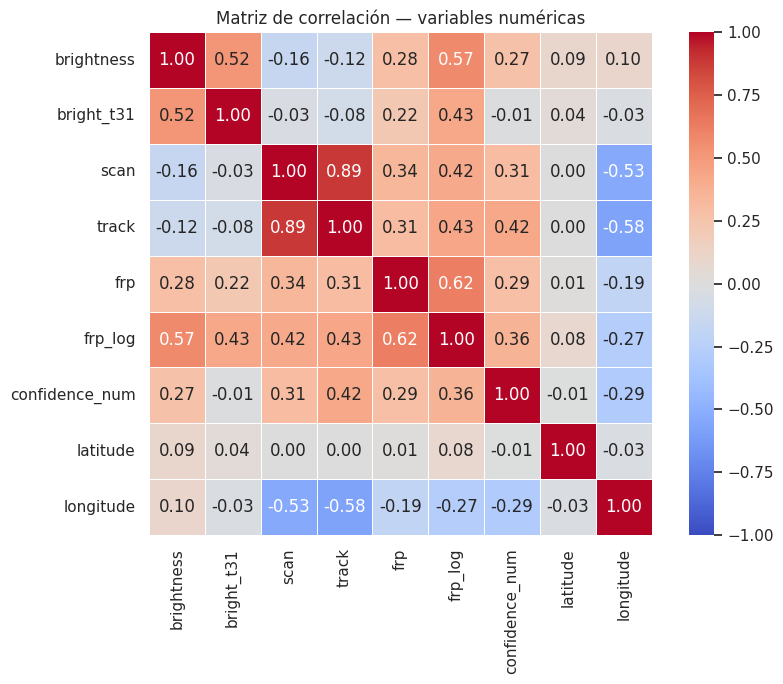

In [14]:
matriz_corr = df[variables_numericas].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title("Matriz de correlación — variables numéricas")
plt.tight_layout()
plt.show()


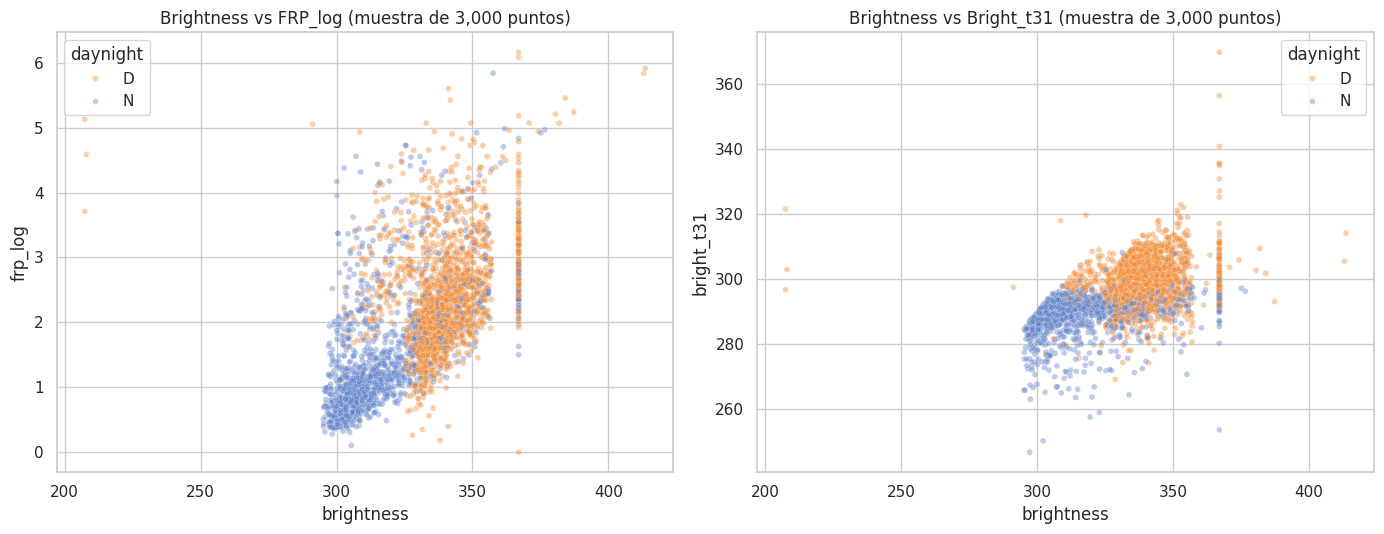

In [15]:
idx_muestra = df.sample(n=3000, random_state=RANDOM_STATE).index

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

sns.scatterplot(data=df.loc[idx_muestra], x="brightness", y="frp_log", hue="daynight",
                 palette={"D": "#F0862E", "N": "#5B7EC9"}, alpha=0.4, s=18, ax=axes[0])
axes[0].set_title("Brightness vs FRP_log (muestra de 3,000 puntos)")

sns.scatterplot(data=df.loc[idx_muestra], x="brightness", y="bright_t31", hue="daynight",
                 palette={"D": "#F0862E", "N": "#5B7EC9"}, alpha=0.4, s=18, ax=axes[1])
axes[1].set_title("Brightness vs Bright_t31 (muestra de 3,000 puntos)")

plt.tight_layout()
plt.show()


## 8. Relación entre variables numéricas y categóricas (boxplots)

¿Cambia la distribución de `brightness` o `frp` según el instrumento, el satélite, o si fue de
día o de noche? Los boxplots muestran mediana, dispersión y outliers de un vistazo.

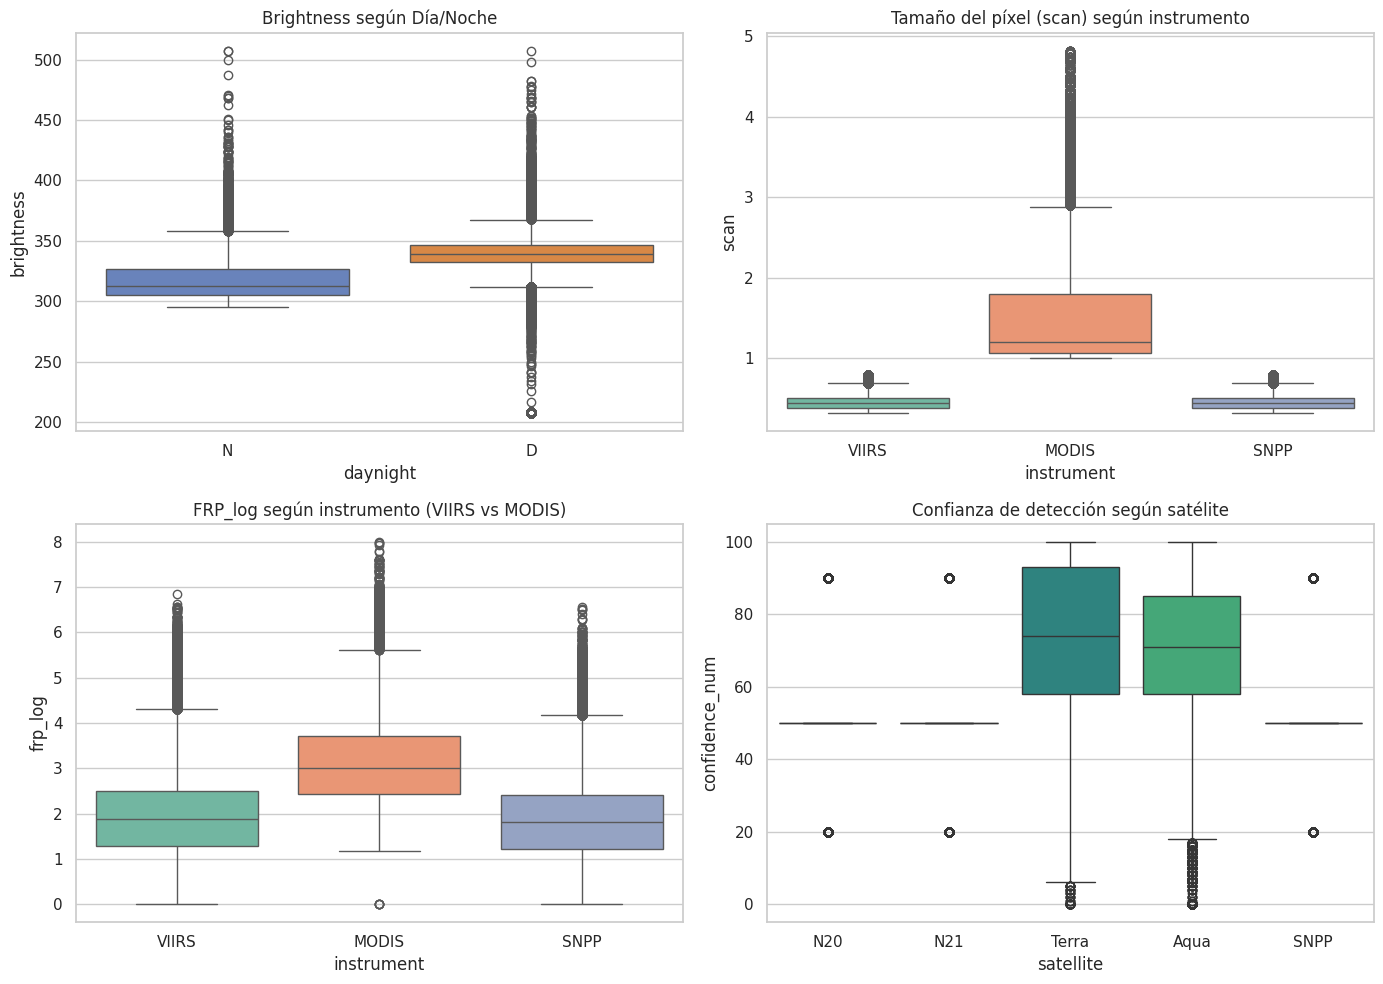

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(data=df, x="daynight", y="brightness", hue="daynight",
            palette={"D": "#F0862E", "N": "#5B7EC9"}, legend=False, ax=axes[0, 0])
axes[0, 0].set_title("Brightness según Día/Noche")

sns.boxplot(data=df, x="instrument", y="scan", hue="instrument",
            palette="Set2", legend=False, ax=axes[0, 1])
axes[0, 1].set_title("Tamaño del píxel (scan) según instrumento")

sns.boxplot(data=df, x="instrument", y="frp_log", hue="instrument",
            palette="Set2", legend=False, ax=axes[1, 0])
axes[1, 0].set_title("FRP_log según instrumento (VIIRS vs MODIS)")

sns.boxplot(data=df, x="satellite", y="confidence_num", hue="satellite",
            palette="viridis", legend=False, ax=axes[1, 1])
axes[1, 1].set_title("Confianza de detección según satélite")

plt.tight_layout()
plt.show()


**Qué buscar aquí:** si `scan` y `frp_log` muestran cajas claramente distintas entre VIIRS y
MODIS, es evidencia visual de que el tamaño del píxel del sensor influye en los valores de FRP
reportados — algo que luego se confirma como hallazgo relevante en los modelos de clasificación
por nivel de intensidad.

## 9. Detección de valores atípicos (outliers)

Usando el criterio estándar de rango intercuartílico (IQR): un valor es atípico si está a más de
1.5 veces el IQR por encima del tercer cuartil o por debajo del primero.

In [17]:
def contar_outliers_iqr(serie):
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = serie[(serie < lim_inf) | (serie > lim_sup)]
    return len(outliers), len(outliers) / len(serie) * 100, lim_inf, lim_sup

resumen_outliers = []
for col in ["brightness", "bright_t31", "scan", "track", "frp", "confidence_num"]:
    n, pct, lim_inf, lim_sup = contar_outliers_iqr(df[col])
    resumen_outliers.append({
        "Variable": col, "N° outliers": n, "% del total": round(pct, 2),
        "Límite inferior": round(lim_inf, 2), "Límite superior": round(lim_sup, 2)
    })

pd.DataFrame(resumen_outliers)


,Variable,N° outliers,% del total,Límite inferior,Límite superior
0,brightness,1245,0.19,273.48,384.24
1,bright_t31,17681,2.63,274.52,316.63
2,scan,76855,11.44,0.18,0.78
3,track,73812,10.99,0.05,0.96
4,frp,66228,9.86,-12.16,27.80
5,confidence_num,138411,20.60,50.00,50.00


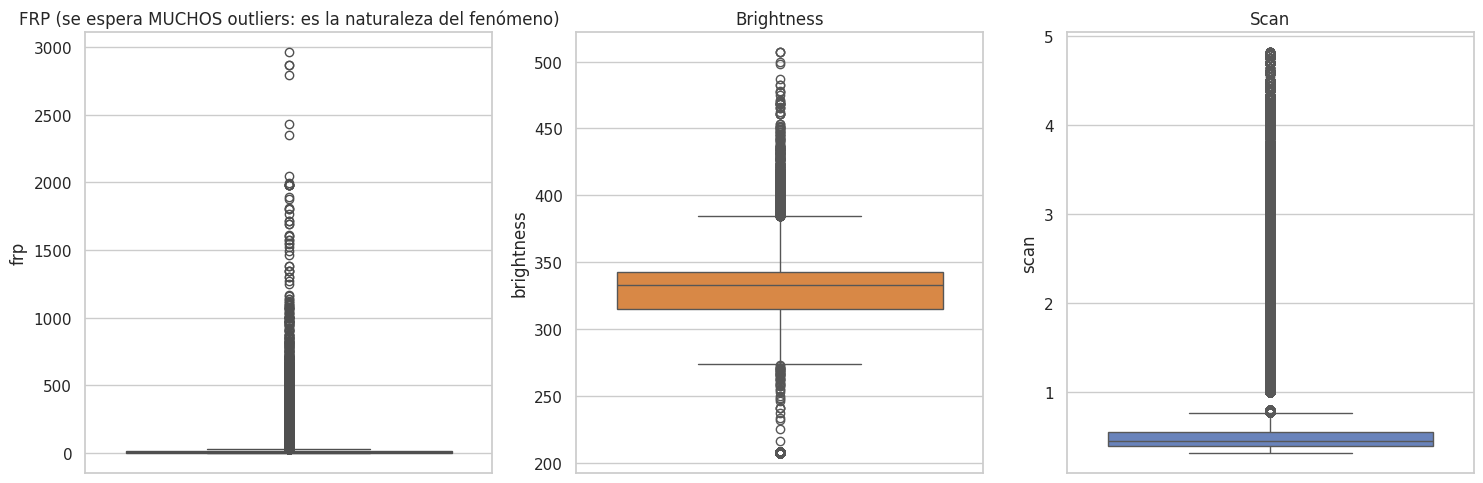

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(y=df["frp"], color="#E8321F", ax=axes[0])
axes[0].set_title("FRP (se espera MUCHOS outliers: es la naturaleza del fenómeno)")

sns.boxplot(y=df["brightness"], color="#F0862E", ax=axes[1])
axes[1].set_title("Brightness")

sns.boxplot(y=df["scan"], color="#5B7EC9", ax=axes[2])
axes[2].set_title("Scan")

plt.tight_layout()
plt.show()


**Importante:** que `frp` tenga muchos "outliers" según el criterio IQR **no significa que
sean errores de medición que haya que eliminar** — son incendios genuinamente más intensos que el
resto, y es justamente la razón por la que se usa `frp_log` en los modelos en vez de filtrar estos
valores.

## 10. Resumen de hallazgos (plantilla a completar con tus propios números)

Completa estas frases con los resultados que te salieron al correr el notebook:

- **Tamaño y calidad:** el dataset tiene ___ filas y ___ valores nulos tras la limpieza.
- **Distribución de FRP:** el FRP crudo está fuertemente sesgado a la derecha (ver Sección 3),
  lo que justifica usar `frp_log` como variable objetivo en los modelos de regresión.
- **Balance Día/Noche:** el ___% de las detecciones son diurnas y el ___% nocturnas (Sección 4).
- **Estacionalidad:** el pico de incendios se concentra en los meses de ___ a ___ (Sección 5).
- **Concentración geográfica:** las zonas con mayor densidad de focos son ___ (Sección 6).
- **Correlaciones más fuertes:** según la matriz de correlación (Sección 7), las variables más
  correlacionadas entre sí son ___ y ___, con un coeficiente de ___.
- **Diferencia entre sensores:** VIIRS y MODIS muestran diferencias claras/no claras en `scan` y
  `frp_log` (Sección 8) — esto es relevante porque ___.
- **Outliers:** la variable con más valores atípicos es ___, y se explica porque ___ (no se
  eliminan, son incendios reales de alta intensidad).
